In [39]:
## Imports:import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.metrics import pairwise_distancesfrom scipy.optimize import minimizeimport random

# 1. Data Preparation:
1.1 Load the dataset and perform necessary preprocessing steps for KNN. Specify and apply these steps as needed.

aside from loading the data

we're going to start by perform a few preprocessing tasks:

    1. dealing with duplicates

    2. dealing with missing values

    3. encoding categorical variables.
    
    4. feature scaling

In [6]:
data = pd.read_csv('P3.csv', index_col=0)data.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,label
0,0.140023,0.265418,-0.535880,0.808262,-0.998551,1.147053,0.979441,0.722351,0.559936,0.399382,1.098400,0.036805,1.302542,-0.239813,0.625914,0.0
1,1.176099,1.690023,-0.737042,1.207350,-1.249740,-0.921881,0.065195,-0.581772,0.645254,-0.089174,-1.571598,0.633757,0.636572,1.233946,-0.300362,1.0
2,1.322751,0.635943,0.012525,0.027479,0.083267,0.447982,1.158902,1.177922,0.887521,0.018378,-0.395321,0.451929,0.744254,-0.492224,-0.316476,1.0
3,0.907289,-0.475599,-1.270970,1.837189,-2.471438,1.270536,-0.536260,-0.852590,0.778421,0.362119,-1.111151,0.153531,-0.342588,-0.147104,-0.585484,0.0
4,0.809604,1.039083,0.869025,-1.204626,1.756469,0.318814,-2.582921,-1.493409,-1.221354,0.435062,-0.068407,0.942154,0.329038,0.375319,-0.843292,1.0


lest check for duplicates 

In [7]:
num_duplicates = data.duplicated().sum()num_duplicates

0

so no duplicates

lets check for the missing values

In [8]:
data.isnull().sum()

f1       0
f2       0
f3       0
f4       0
f5       0
f6       0
f7       0
f8       0
f9       0
f10      0
f11      0
f12      0
f13      0
f14      0
f15      0
label    0
dtype: int64

so no null values as well

so lest check the format of each feature, to see if we have any categorical features to encode

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      300 non-null    float64
 1   f2      300 non-null    float64
 2   f3      300 non-null    float64
 3   f4      300 non-null    float64
 4   f5      300 non-null    float64
 5   f6      300 non-null    float64
 6   f7      300 non-null    float64
 7   f8      300 non-null    float64
 8   f9      300 non-null    float64
 9   f10     300 non-null    float64
 10  f11     300 non-null    float64
 11  f12     300 non-null    float64
 12  f13     300 non-null    float64
 13  f14     300 non-null    float64
 14  f15     300 non-null    float64
 15  label   300 non-null    float64
dtypes: float64(16)
memory usage: 39.8 KB


looks like all the values are 'float' so nothing to encode

ok, so lets do a bit of 'feature scaling'

so for KNN, there are 2 main methods, 'z-score' and 'min-max', but which one is better ? 

a bit of research shows Min-Max Scaling is often preferred when you want to maintain the relationships between values. However, it's sensitive to outliers since they can significantly affect the range.

Standardization is typically more robust to outliers and is often the go-to method when the features have different units or scales.

so looks like we have to see if we have a lot of outliers or not, then we can find the best feature scaler.

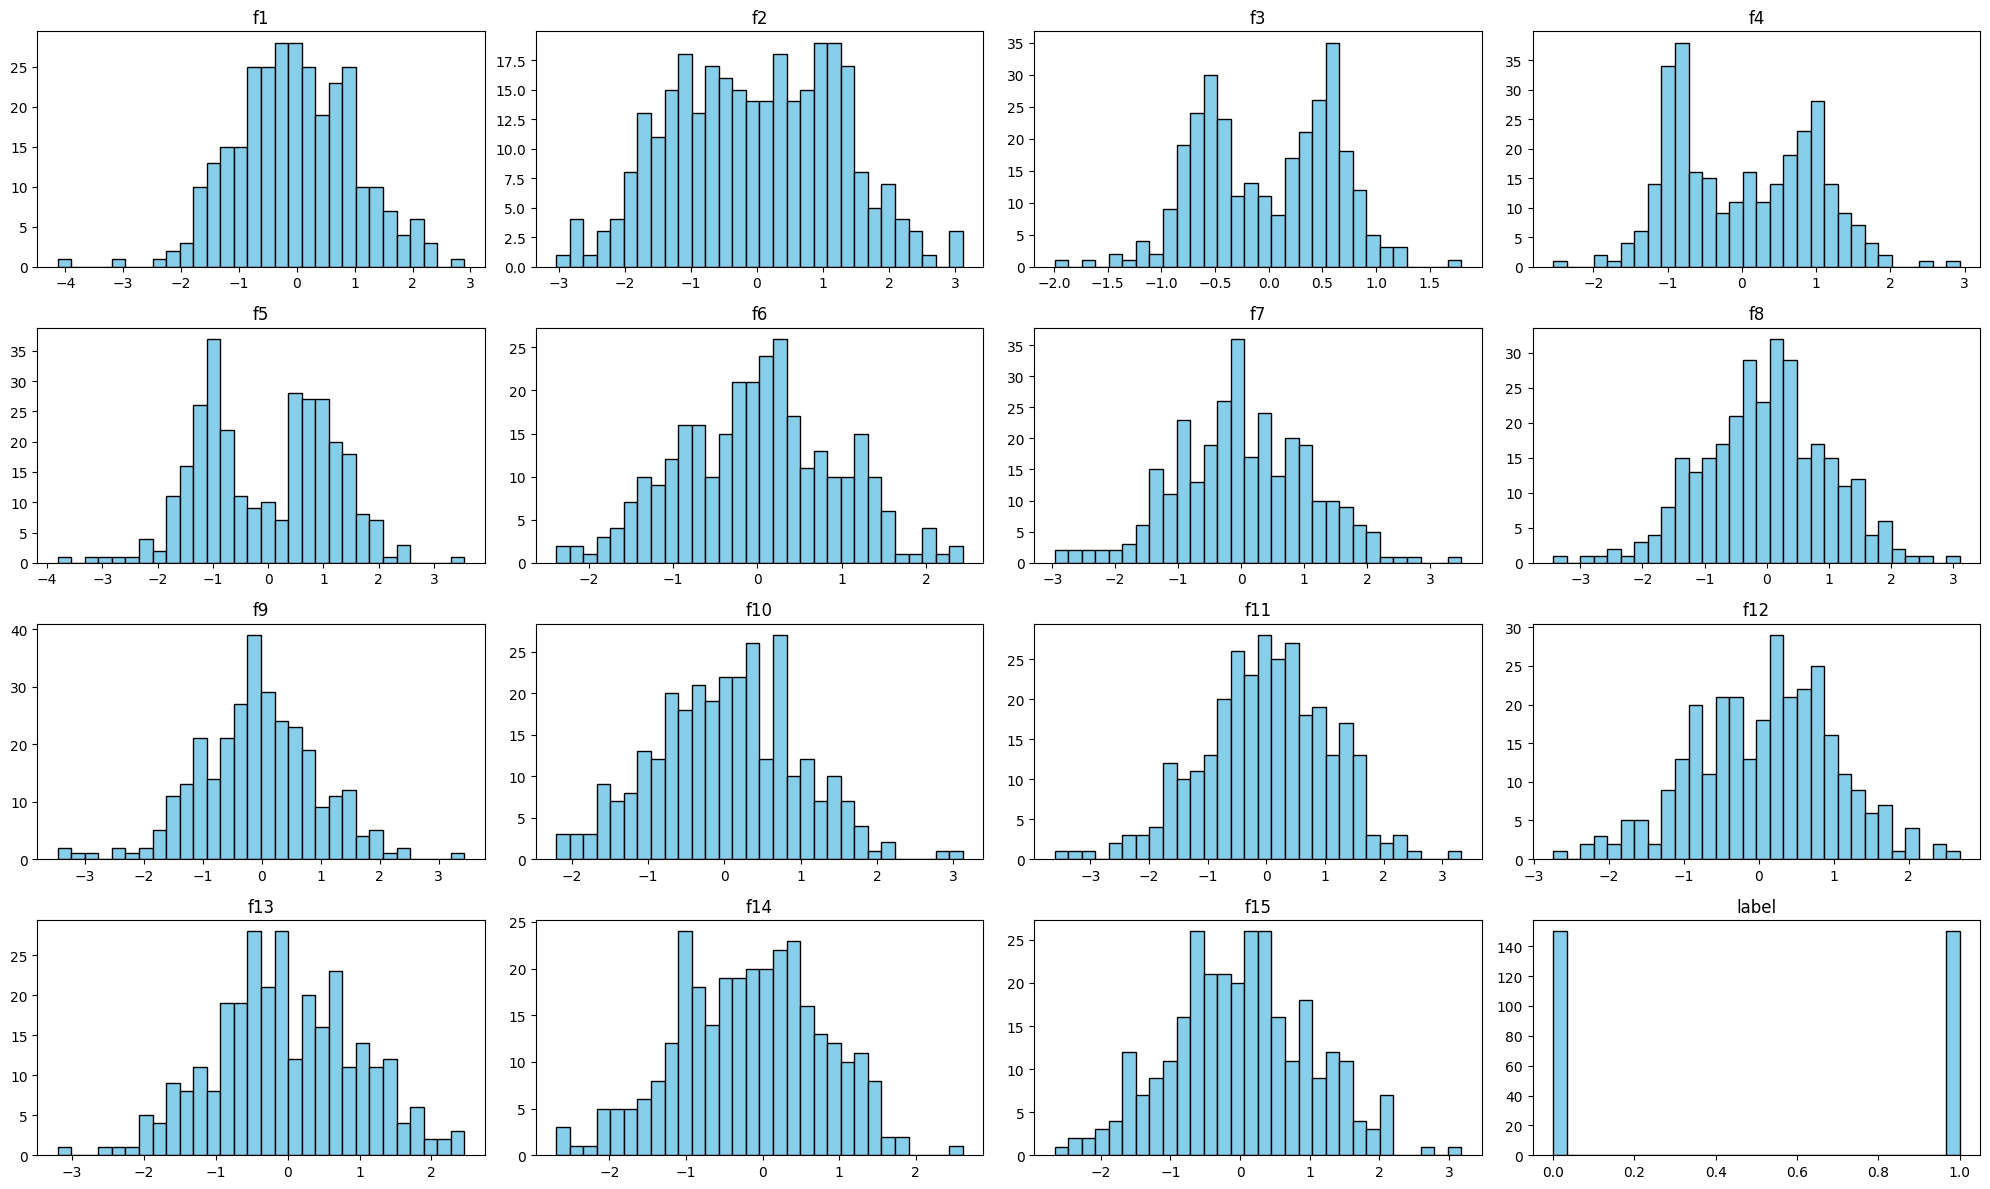

In [10]:
fig, axs = plt.subplots(4, 4, figsize=(20, 12))axs = axs.flatten()for i, column in enumerate(data.columns):    axs[i].hist(data[column], bins=30, color='skyblue', edgecolor='black')    axs[i].set_title(column)# Removeunused subplotsfor j in range(i + 1, len(axs)):    fig.delaxes(axs[j])plt.tight_layout()plt.show()

except the 'lable' which is binary and understandable, and 'f3', 'f4', and 'f5', the rest of the features look normaly distributed


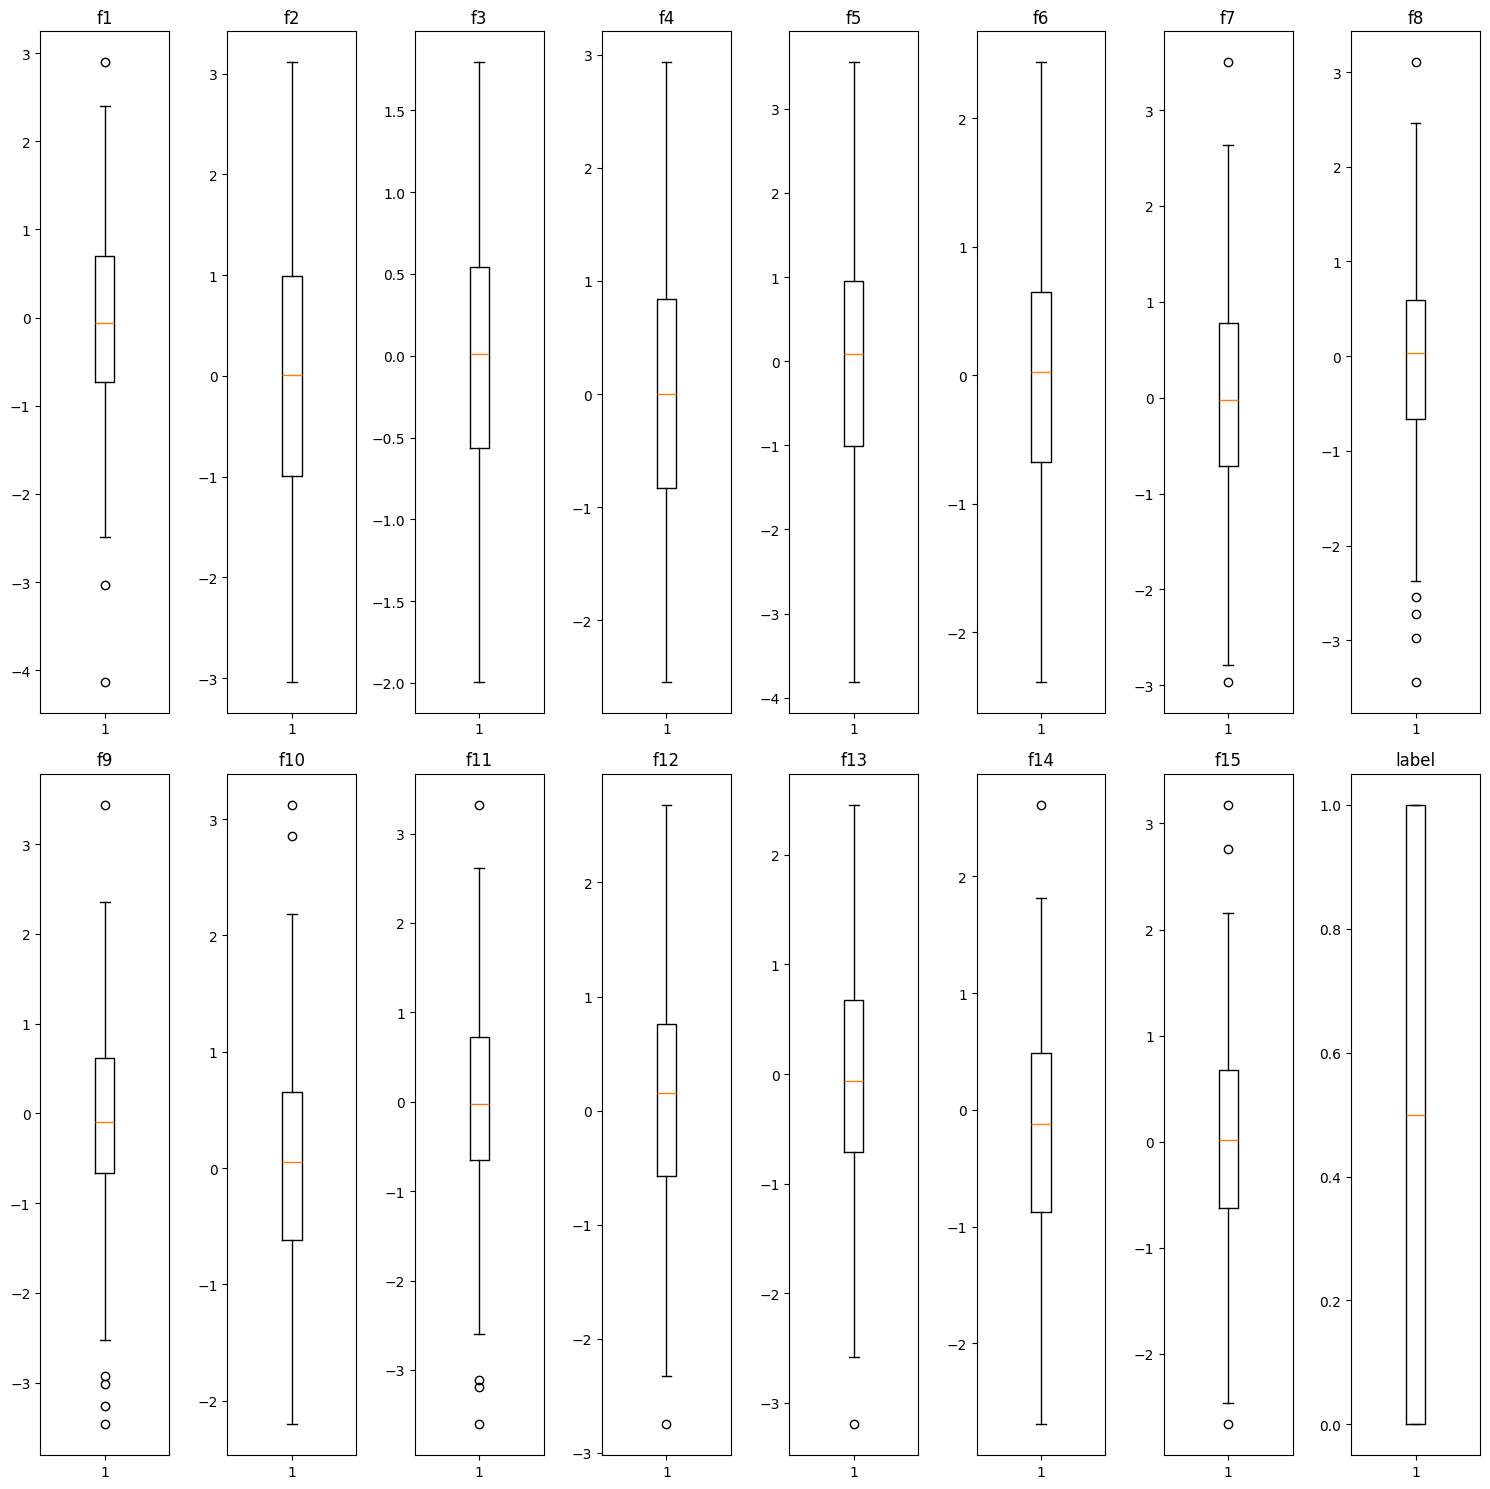

In [11]:
fig, axs = plt.subplots(2, 8, figsize=(15, 15))axs = axs.flatten()# distribution of each featurefor i, column in enumerate(data.columns):    axs[i].boxplot(data[column])    axs[i].set_title(column)# Remove unused subplotsfor j in range(i + 1, len(axs)):    fig.delaxes(axs[j])plt.tight_layout()plt.show()

seems like we have a fair amount of outliers, looking back at what we said about 'z-score' and 'min-max', we now can choose the 'z-score'

In [12]:
z_scaled_data = data.drop('label', axis=1)

In [13]:
z_scaled_data = (z_scaled_data - z_scaled_data.mean()) / z_scaled_data.std()z_scaled_data

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15
0,0.168925,0.229620,-0.823515,0.831189,-0.808172,1.211696,0.894946,0.741812,0.622275,0.402913,1.025450,-0.043782,1.325190,-0.080274,0.609677
1,1.178086,1.373696,-1.140527,1.251011,-1.017193,-0.986303,0.027230,-0.546134,0.707267,-0.121769,-1.447432,0.586172,0.658921,1.469705,-0.312097
2,1.320928,0.527183,0.040719,0.009841,0.092037,0.469015,1.065274,1.191733,0.948610,-0.006264,-0.357995,0.394292,0.766651,-0.345739,-0.328132
3,0.916259,-0.365478,-1.981946,1.913573,-2.033801,1.342881,-0.543616,-0.813593,0.839927,0.362895,-1.020978,0.079397,-0.320678,0.017229,-0.595832
4,0.821112,0.850937,1.390483,-1.286278,1.484354,0.331789,-2.486116,-1.446464,-1.152221,0.441231,-0.055216,0.911618,0.351249,0.566672,-0.852387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,-1.335683,-0.750864,-1.344556,1.250600,-1.428367,0.187107,-0.844190,0.591972,-1.081449,2.306487,-0.019378,0.889063,0.467911,0.680593,1.238670
296,0.756055,-0.064731,1.284735,-1.268946,1.289179,0.462653,1.686977,-0.114637,-1.200574,0.382226,-0.610967,0.323195,-0.383907,0.468623,0.006202
297,-0.236508,-1.397718,0.727651,-0.847449,0.598554,0.165875,0.798859,-0.624129,-0.200568,1.421919,0.737402,-0.507733,0.426004,-1.439095,0.116159
298,1.688198,-1.164425,0.845690,-0.941408,0.740136,-0.260230,0.090362,1.232788,-1.059290,0.668807,1.128364,-1.276351,-0.091080,-1.195009,-0.336147


In [14]:
z_scaled_data['label'] = data['label']

In [15]:
z_scaled_data

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,label
0,0.168925,0.229620,-0.823515,0.831189,-0.808172,1.211696,0.894946,0.741812,0.622275,0.402913,1.025450,-0.043782,1.325190,-0.080274,0.609677,0.0
1,1.178086,1.373696,-1.140527,1.251011,-1.017193,-0.986303,0.027230,-0.546134,0.707267,-0.121769,-1.447432,0.586172,0.658921,1.469705,-0.312097,1.0
2,1.320928,0.527183,0.040719,0.009841,0.092037,0.469015,1.065274,1.191733,0.948610,-0.006264,-0.357995,0.394292,0.766651,-0.345739,-0.328132,1.0
3,0.916259,-0.365478,-1.981946,1.913573,-2.033801,1.342881,-0.543616,-0.813593,0.839927,0.362895,-1.020978,0.079397,-0.320678,0.017229,-0.595832,0.0
4,0.821112,0.850937,1.390483,-1.286278,1.484354,0.331789,-2.486116,-1.446464,-1.152221,0.441231,-0.055216,0.911618,0.351249,0.566672,-0.852387,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,-1.335683,-0.750864,-1.344556,1.250600,-1.428367,0.187107,-0.844190,0.591972,-1.081449,2.306487,-0.019378,0.889063,0.467911,0.680593,1.238670,0.0
296,0.756055,-0.064731,1.284735,-1.268946,1.289179,0.462653,1.686977,-0.114637,-1.200574,0.382226,-0.610967,0.323195,-0.383907,0.468623,0.006202,0.0
297,-0.236508,-1.397718,0.727651,-0.847449,0.598554,0.165875,0.798859,-0.624129,-0.200568,1.421919,0.737402,-0.507733,0.426004,-1.439095,0.116159,0.0
298,1.688198,-1.164425,0.845690,-0.941408,0.740136,-0.260230,0.090362,1.232788,-1.059290,0.668807,1.128364,-1.276351,-0.091080,-1.195009,-0.336147,0.0


lets check the correlation between our features

<Axes: >

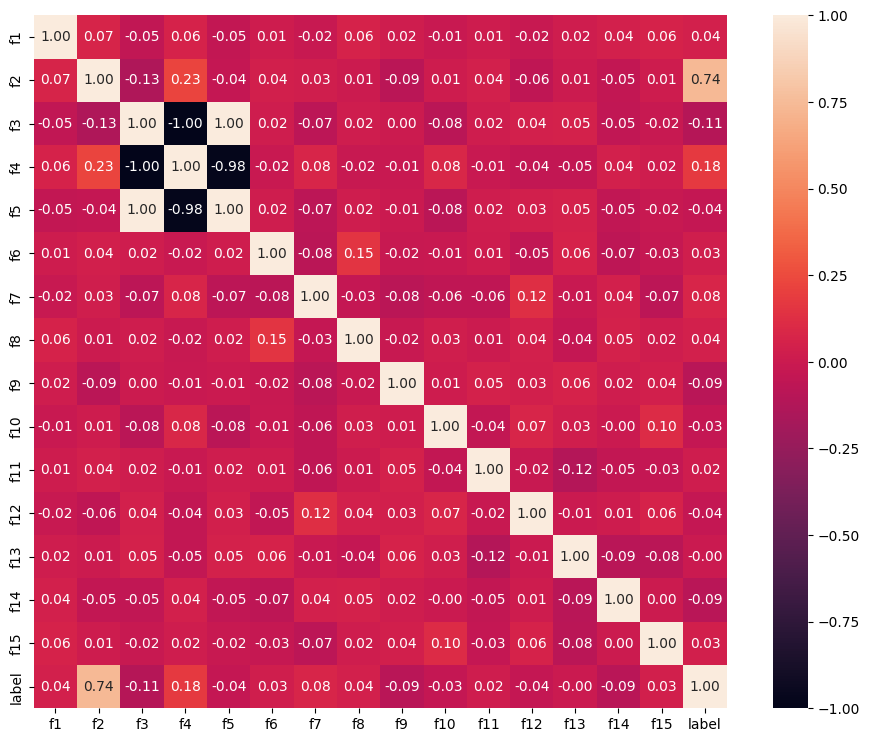

In [16]:
plt.figure(figsize=(12, 9))sns.heatmap(z_scaled_data.corr(numeric_only=True), annot=True, annot_kws={'size': 10}, fmt='.2f', square=True, vmax=1, vmin=-1)

wow, the corralation between 'f3', 'f4' and 'f5' is so strong that we can argue they show the exact same thing.

the corralation between 'f2' and 'label' is fairly strong as well (not as strong as the ones we already mentioned)

we probably are going to remove 2 of the first 3 we mentioned.

just by looking at the heatmap, i would say lets drop the 'f4' and 'f5', because they have literal '1' and '-1' correlation with 'f3' but dont have perfect correlation with each other, so 'f3' should keep more information about the other 2, than the other 2 could have kept about each other.

but i saw a snipet of code on the internet that calculates the correlation matrix

In [17]:
to_drop = ['f4', 'f5']z_scaled_data = z_scaled_data.drop(to_drop, axis=1)

I feel like this is enough preprocessing

1.2. Split the dataset into training and test sets in a 0.9:0.1 ratio

In [18]:
X = z_scaled_data.drop('label', axis=1)y = z_scaled_data['label']

In [19]:
np.random.seed(42)indices = np.arange(len(X))np.random.shuffle(indices)split_index = int(len(X) * 0.9)# train_data = z_scaled_data[:split_index]# test_data = z_scaled_data[split_index:]# print(train_data.shape)# print(test_data.shape)train_indices = indices[:split_index]test_indices = indices[split_index:]X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

# 2. Weighted KNN Loss Calculation -> Implement a function to calculate the loss of a weighted KNN. Follow these steps:

    2.1. For each observation in the dataset, calculate the weighted distance between it and all other observations (using pairwise_distances from scikit-learn is recommended). Use the weighted distance formula provided above.

    2.2. Use the calculated distances to select the k nearest neighbors for each observation and predict the label.

    2.3. Compute a performance metric (e.g., accuracy, AUC, or Log Loss) based on predictions. Return the result without using pre-built functions for metric calculations.

    2.4. This function should accept the weights, dataset, and k as inputs and output the calculated loss.


idk why the person writing the tasks would put 'split the data' in the first task and then in the next say 'the input should be datast', like idk what to do, split the data inside the function ? or just take every splitted part as an input.

i went with the second one.

In [44]:
def weighted_knn_loss(weights, X_train, y_train, X_test, y_test, k):    def weighted_distance(u, v):        return np.sqrt(np.sum(np.abs(weights) * (u - v) ** 2))    # pairwise distances    train_distances = pairwise_distances(X_train, metric=lambda u, v: weighted_distance(u, v))    # predictions for the training set    train_predictions = np.zeros(len(X_train))    for i in range(len(X_train)):        nearest_indices = np.argsort(train_distances[i])[:k]        nearest_labels = y_train.iloc[nearest_indices].values        train_predictions[i] = np.bincount(nearest_labels.astype(int)).argmax() ## predicts by counting    # pairwise distances for the test set based on the training set    test_distances = pairwise_distances(X_test, X_train, metric=lambda u, v: weighted_distance(u, v))    # predictions for the test set    test_predictions = np.zeros(len(X_test))    for i in range(len(X_test)):        nearest_indices = np.argsort(test_distances[i])[:k]        nearest_labels = y_train.iloc[nearest_indices].values        test_predictions[i] = np.bincount(nearest_labels.astype(int)).argmax()    # accuracy for the test set    test_accuracy = np.mean(test_predictions == y_test.values)    # loss = (1 - accuracy)    return 1 - test_accuracy

In [45]:
weights = np.ones(X.shape[1])k = 5loss = weighted_knn_loss(weights, X_train, y_train, X_test, y_test, k)print(f'Weighted KNN Loss: {loss}')

Weighted KNN Loss: 0.23333333333333328


# 3. Initialize weights to zero and optimize the function from Step 2 to find the best weights that minimize KNN classification loss (using scipy.optimize.minimize for optimization is recommended).

In [34]:
def optimize_weights(X_train, y_train, X_test, y_test, k):    # Initialize weights to zero    initial_weights = np.zeros(X_train.shape[1])    # function to minimize    def objective(weights):        return weighted_knn_loss(weights, X_train, y_train, X_test, y_test, k)    # Use scipy.optimize.minimize to find the optimal weights    result = minimize(objective, initial_weights, method='BFGS') ## it attempts to find the minimum of a given objective function (objective)                                                            ## starting from an initial guess (initial_weights) using the BFGS optimization algo.    # Optimal weights and the minimized loss    optimal_weights = result.x    optimal_loss = result.fun    return optimal_weights, optimal_loss

note that we're going to run the 'optimize_weights' with the value of 'k' set to '5', this took more than 5 minutes to run.

In [46]:
k=5weights = np.zeros(X.shape[1])optimal_weights, optimal_loss = optimize_weights(X_train, y_train, X_test, y_test, k=k)

In [47]:
print("Optimal Weights:", optimal_weights)print("Optimal Loss:", optimal_loss)

Optimal Weights: [ 6.21557316e-06  3.72934390e-05  2.17545061e-05  0.00000000e+00
  1.24311463e-05  9.32335975e-06  1.86467195e-05 -3.10778658e-06
 -6.21557316e-06  3.10778658e-06  6.21557316e-06  0.00000000e+00
  6.21557316e-06]
Optimal Loss: 0.16666666666666663


# 4. Weighted and Vanilla KNN Classification

Implement the weighted KNN classifier using the optimized weights from Step 3 to predict labels
for the test set.

Additionally, classify the test set using vanilla KNN (weighted KNN with all weights set to one)
and compare the results.

In [48]:
optimized_loss = weighted_knn_loss(optimal_weights, X_train, y_train, X_test, y_test, k)optimized_loss

0.16666666666666663

i did set the value of 'k' to '5' because we found the optimized weight considering it as such.

In [49]:
k = 5weights = np.ones(X.shape[1])vanilla_loss = weighted_knn_loss(weights, X_train, y_train, X_test, y_test, k)optimized_loss = weighted_knn_loss(optimal_weights, X_train, y_train, X_test, y_test, k)print(f'Vanilla KNN Loss: {vanilla_loss}\nvs\nOptimized KNN loss: {optimized_loss}')

Vanilla KNN Loss: 0.23333333333333328
vs
Optimized KNN loss: 0.16666666666666663


# 5. Dimensionality Reduction Using Random Feature Subsets:
Select 8 random subsets of features, each containing 5 features, and use them for classification.
Report the results.

In [50]:
def knn_with_feature_subset(X_train, y_train, X_test, y_test, feature_subset, weights, k=5):    # Select only the subset of features    X_train_subset = X_train[feature_subset]    X_test_subset = X_test[feature_subset]    feature_indices = [X_train.columns.get_loc(f) for f in feature_subset]    subset_weights = weights[feature_indices]    loss = weighted_knn_loss(subset_weights, X_train_subset, y_train, X_test_subset, y_test, k)    # accuracy    accuracy = 1 - loss    return accuracy

In [65]:
feature_names = X_train.columnssubsets = []accuracies = []num_subsets = 8num_features_per_subset = 5# Loop to select random subsets and evaluate KNNfor _ in range(num_subsets):    # Randomly sampling subset of features    feature_subset = random.sample(list(feature_names), num_features_per_subset)    # Store the subset    subsets.append(feature_subset)    # Evaluate KNN with subset    accuracy = knn_with_feature_subset(X_train, y_train, X_test, y_test, feature_subset, weights, k=5)    accuracies.append(accuracy)for i, (subset, accuracy) in enumerate(zip(subsets, accuracies), start=1):    print(f"Subset {i}: {subset}")    print(f"Accuracy: {accuracy * 100:.2f}%")    print(f"Loss: {1 - accuracy}\n")

Subset 1: ['f9', 'f12', 'f3', 'f14', 'f10']
Accuracy: 50.00%
Loss: 0.5

Subset 2: ['f14', 'f11', 'f15', 'f12', 'f3']
Accuracy: 56.67%
Loss: 0.43333333333333335

Subset 3: ['f7', 'f14', 'f1', 'f10', 'f2']
Accuracy: 80.00%
Loss: 0.19999999999999996

Subset 4: ['f6', 'f2', 'f14', 'f7', 'f11']
Accuracy: 80.00%
Loss: 0.19999999999999996

Subset 5: ['f3', 'f2', 'f13', 'f14', 'f6']
Accuracy: 76.67%
Loss: 0.23333333333333328

Subset 6: ['f12', 'f11', 'f3', 'f10', 'f8']
Accuracy: 53.33%
Loss: 0.4666666666666667

Subset 7: ['f8', 'f3', 'f9', 'f6', 'f7']
Accuracy: 56.67%
Loss: 0.43333333333333335

Subset 8: ['f7', 'f14', 'f9', 'f8', 'f15']
Accuracy: 50.00%
Loss: 0.5

